In [17]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from sklearn.tree import DecisionTreeClassifier, plot_tree
from lifelines import KaplanMeierFitter
import torch
from swotted.utils import success_rate


project_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    src_candidate = base / "src" / "trajectoryclusteringanalysis"
    if src_candidate.exists():
        project_root = base
        break

if project_root is None:
    raise FileNotFoundError(
        f"Could not find project root containing src/trajectoryclusteringanalysis from {Path.cwd()}"
    )

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from trajectoryclusteringanalysis import TCA
from trajectoryclusteringanalysis.plotting import *

print(f"Using local package from: {src_path}")

from trajectoryclusteringanalysis.tca import TCA

Using local package from: c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src


In [18]:
df = pd.read_csv(project_root / "data" / "multidimensional_data.csv")
df

,PATIENT_ID,EVENT,TIME
0,1,Chirurgie,0
1,1,Chimiothérapie IV,1
2,1,Chimiothérapie IV,1
3,1,Chimiothérapie IV,2
4,1,Chimiothérapie IV,3
...,...,...,...
20430,1336,Chimiothérapie IV,2
20431,1336,Chimiothérapie IV,2
20432,1336,Chimiothérapie IV,3
20433,1336,Chimiothérapie IV,3


In [19]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
timed_event_structure = df.copy()

timed_event_structure['Event'] = label_encoder.fit_transform(timed_event_structure['EVENT'])
timed_event_structure.drop(columns=['EVENT'], inplace=True)
timed_event_structure.columns = ['ID_PATIENT', 'Time', 'Event']
noms_events = label_encoder.classes_
timed_event_structure

,ID_PATIENT,Time,Event
0,1,0,2
1,1,1,0
2,1,1,0
3,1,2,0
4,1,3,0
...,...,...,...
20430,1336,2,0
20431,1336,2,0
20432,1336,3,0
20433,1336,3,0


In [20]:
nunique = timed_event_structure['ID_PATIENT'].nunique()
print(f"Number of unique patients: {nunique}")

Number of unique patients: 1336


In [21]:
# Get the set of all unique Event values
unique_events = timed_event_structure['Event'].unique()
all_events = set(unique_events)

# Find patients who have all occurrences of Event
patients_with_all_events = timed_event_structure.groupby('ID_PATIENT').filter(
    lambda group: set(group['Event']) == all_events
)['ID_PATIENT'].unique()

print(f"Patients with all occurrences of Event: {len(patients_with_all_events)}")
print(patients_with_all_events)

Patients with all occurrences of Event: 50
[   8   23   45   65   66  134  157  173  176  178  188  194  220  228
  242  275  312  343  361  390  428  466  469  472  478  537  544  546
  575  613  665  673  688  759  775  790  792  831  845  867  895  937
  943  969  984 1081 1126 1286 1293 1333]


In [22]:
# Créer une instance de TCA pour l'analyse multidimensionnelle
tca = TCA(data=timed_event_structure,
              index_col='ID_PATIENT',
              time_col='Time', 
              event_col='Event',
              mode='multidimensional',
              )

INFO:root:TCA object initialized successfully


Dataset :
data shape:  (20435, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3


INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.


In [23]:
tca.analyzer.transform_time_event_structure_to_tensor()
print("Tensor shape:", tca.analyzer.get_tensor_shape())
tensor = tca.analyzer.get_tensor()

Tensor shape: torch.Size([1336, 4, 24])


In [24]:
# Hyperparametres de la demo
rank = 3
reg_term_ns = 0.5
reg_term_s = 0.5
metric = 'Bernoulli'
learning_rate = 1e-3
n_epochs = 300  # 30 pour demo rapide, 100+ pour entrainement plus stable

Patient utilise pour la visualisation: 8


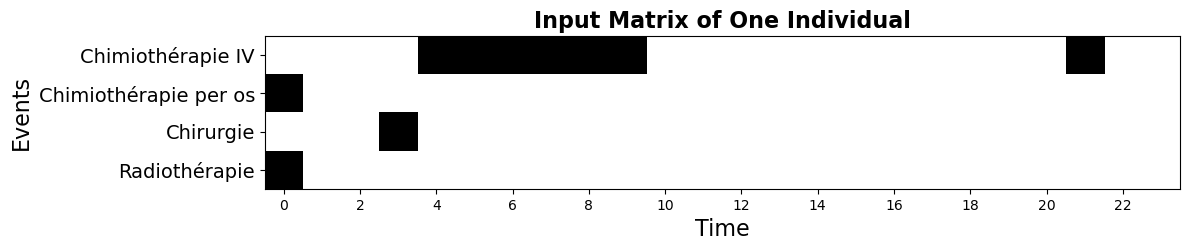

     PATIENT_ID                  EVENT  TIME
143           8  Chimiothérapie per os     0
144           8          Radiothérapie     0
145           8          Radiothérapie     0
146           8          Radiothérapie     0
147           8          Radiothérapie     0
148           8          Radiothérapie     0
149           8          Radiothérapie     0
150           8          Radiothérapie     0
151           8              Chirurgie     3
152           8              Chirurgie     3
153           8      Chimiothérapie IV     4
154           8      Chimiothérapie IV     5
155           8      Chimiothérapie IV     6
156           8      Chimiothérapie IV     6
157           8      Chimiothérapie IV     7
158           8      Chimiothérapie IV     7
159           8      Chimiothérapie IV     7
160           8      Chimiothérapie IV     8
161           8      Chimiothérapie IV     8
162           8      Chimiothérapie IV     9
163           8      Chimiothérapie IV     9
164       

In [25]:
patient_index = int(patients_with_all_events[0])
print(f"Patient utilise pour la visualisation: {patient_index}")

plot_input_matrix(tensor, id=patient_index, labels=noms_events)

print(df[df['PATIENT_ID'] == 8])

Rien au mois 10, alors qu'il y a une chimiothérapie IV, et "déplacé" au mois 21

Pareil, le mois 10, 14 et 20 on a rien.

In [ ]:
tca.analyzer.fit_swotted_decomposition(
        tensor=tensor,
        rank=rank,
        time_window_length=3,
        reg_term_ns=reg_term_ns,
        reg_term_s=reg_term_s,
        metric=metric,
        learning_rate=learning_rate,
        n_epochs=n_epochs
    )

tca.analyzer.get_decomposition_results(labels=noms_events, id=patient_index)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelChec

Training: |          | 0/? [00:00<?, ?it/s]

In [ ]:
tailles_fenetres = [2, 3, 4, 5] 

for w in tailles_fenetres:
    print("\n" + "="*60)
    print(f" ANALYSE DES PLOTS POUR UNE TAILLE DE FENÊTRE (WINDOW) : {w} ")
    print("="*60 + "\n")

    tca.analyzer.fit_swotted_decomposition(
        tensor=tensor,
        rank=rank,
        time_window_length=w,
        reg_term_ns=reg_term_ns,
        reg_term_s=reg_term_s,
        metric=metric,
        learning_rate=learning_rate,
        n_epochs=n_epochs
    )

    tca.analyzer.get_decomposition_results(labels=noms_events, id=patient_index)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
# Choisir MinMaxscaler pour avoir des intensités entre 0 et 1

ph_intensity = tca.analyzer.to_phenotype_intensity(scaler=MinMaxScaler())
print("Shape intensites:", ph_intensity.shape)
ph_intensity.head()

Shape intensites: (1336, 4)


,Phenotype_1,Phenotype_2,Phenotype_3,ID_PATIENT
0,0.399326,0.432825,0.466279,1
1,0.621835,0.322439,0.574350,2
2,0.765598,0.605527,0.314826,3
3,0.420055,0.368026,0.167677,4
4,0.428319,0.603123,0.478652,5


INFO:root:Calculating distance matrix using metric: euclidean...
INFO:root:Time taken for computation: 0.01 seconds
INFO:root:Computing the linkage matrix using method: ward...
c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src\trajectoryclusteringanalysis\unidimensional\clustering.py:238: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(condensed_distance_matrix, method=method, optimal_ordering=optimal_ordering)
INFO:root:Linkage matrix computed successfully


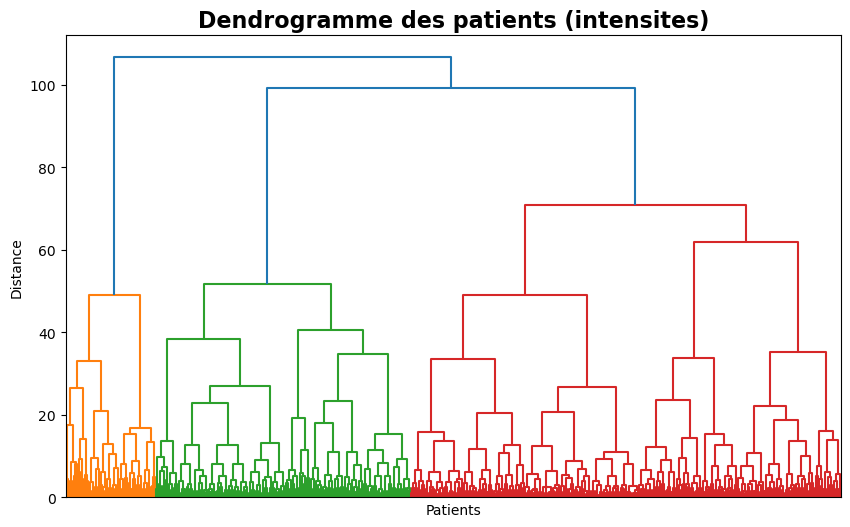

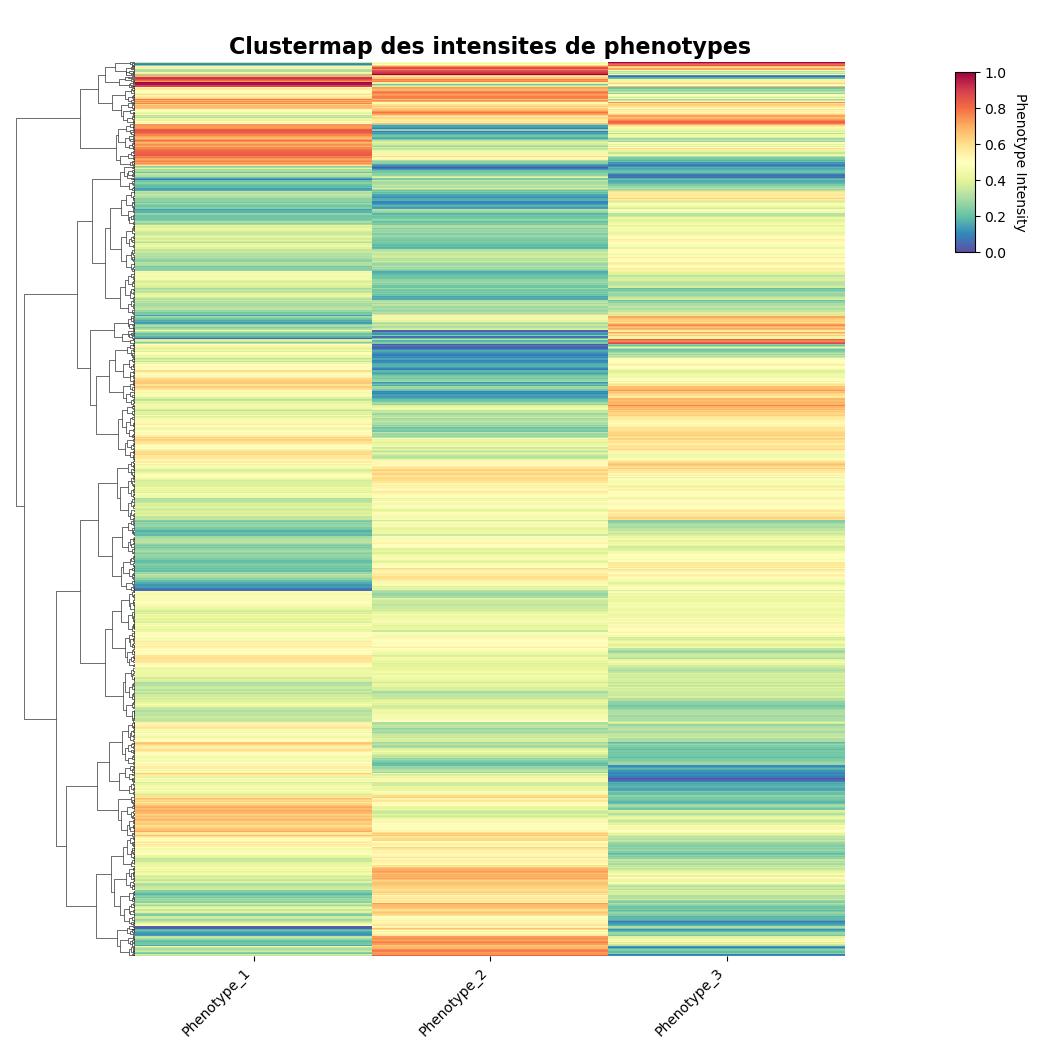

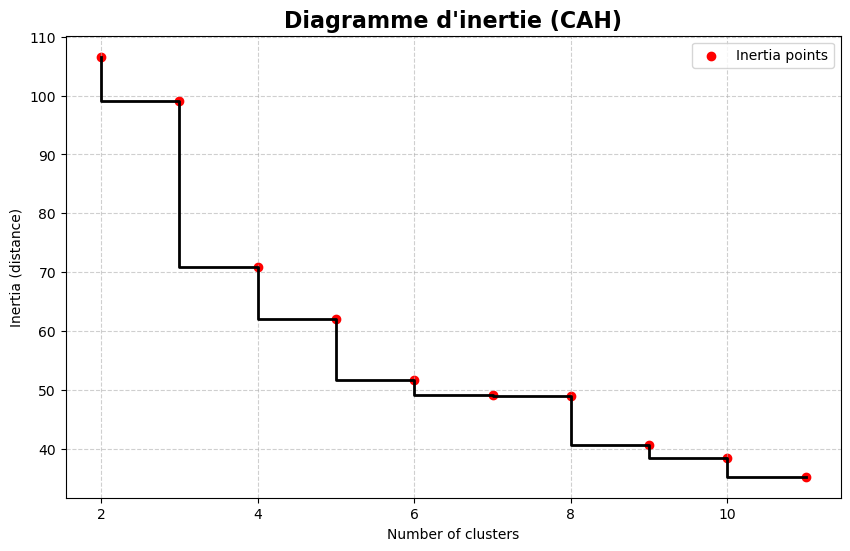

In [ ]:
distance_matrix = tca.compute_distance_matrix(data=ph_intensity, metric='euclidean')
linkage_matrix = tca.hierarchical_clustering(distance_matrix)

# Visualisations standard du package
tca.plot_dendrogram(linkage_matrix, title='Dendrogramme des patients (intensites)')
tca.plot_clustermap(ph_intensity, linkage_matrix, title='Clustermap des intensites de phenotypes')

tca.plot_inertia(linkage_matrix, title="Diagramme d'inertie (CAH)")

Choisir 4 clusters semble intéressant

Effectifs par cluster:
1    155
2    440
3    392
4    349
Name: count, dtype: int64


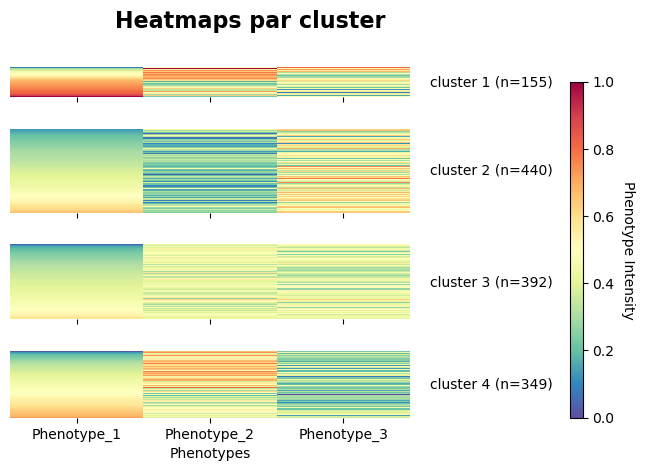

In [ ]:
clusters = tca.assign_clusters(linkage_matrix, num_clusters=4)
print("Effectifs par cluster:")
print(pd.Series(clusters).value_counts().sort_index())

tca.plot_cluster_heatmaps(ph_intensity, clusters, sorted=True, title='Heatmaps par cluster')